# Section 3 - Exploratory analysis & the story

**Goal of this notebook.** Find the narrative in the cleaned modelling table -
which contract characteristics line up with single-bidding, and which of them are
useful, non-circular signals for the model later. Section 1 already covered the
target balance, the `procedure` near-circularity, and the `sector_code` (CPV)
breakdown, so this notebook focuses on the dimensions not yet explored:

1. **EU funding** (`eu_funded`) - does extra EU oversight draw more bidders?
2. **Authority type** (`type_group`) - which kinds of body see least competition?
3. **Region** - geographic variation in single-bidding.
4. **Time** - engineer `month`, `quarter`, `is_year_end` from `signed_at`, and
   check whether timing (e.g. a year-end rush) tracks single-bidding.
5. **Consolidate the `procedure` circularity** into the EDA narrative as the
   headline trap (measured in Section 1, handled at the modelling stage).

Each breakdown shows the rate *with its contract count*, so no finding rests on a
group too small to trust. Findings and the decisions they imply are collected in
the closing cell.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the cleaned modelling table built in Section 2.
modelling = pd.read_csv("../data/processed/contracts-modelling.csv")
overall_rate = modelling["single_bid"].mean()

print(f"modelling table: {modelling.shape[0]:,} rows x {modelling.shape[1]} columns")
print(f"overall single-bid rate: {overall_rate:.1%}")

modelling table: 174,119 rows x 17 columns
overall single-bid rate: 44.9%


In [2]:
# Small helper: single-bid rate by a column, with single-bid count and total,
# sorted by rate.
def rate_by(col, sort_by_rate=True):
    g = (modelling.groupby(col)["single_bid"]
         .agg(single_bid_rate="mean", n_single_bid="sum", n_contracts="count"))
    g["n_single_bid"] = g["n_single_bid"].astype(int)
    return g.sort_values("single_bid_rate", ascending=False) if sort_by_rate else g.sort_index()

## 1. Single-bid rate by EU funding

EU-funded contracts face extra publication and procurement-oversight rules, so a
natural question is whether that scrutiny draws more bidders. Comparing the
single-bid rate for EU-funded vs. nationally-funded contracts tests it directly.

           single_bid_rate  n_single_bid  n_contracts
eu_funded                                            
0                    0.463         69463       149953
1                    0.360          8695        24166


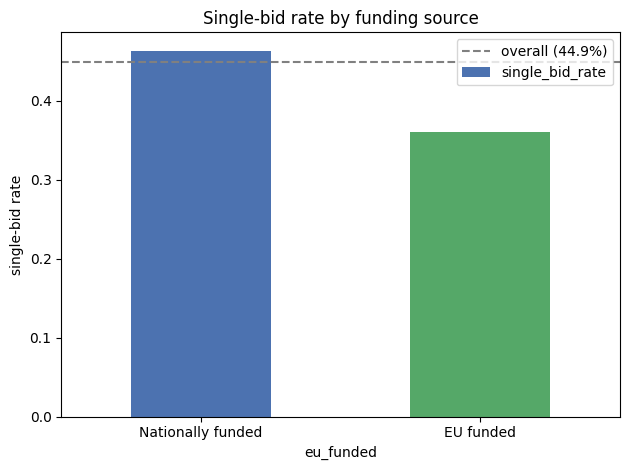

In [3]:
eu = rate_by("eu_funded", sort_by_rate=False)
print(eu.assign(single_bid_rate=eu["single_bid_rate"].round(3)).to_string())

ax = eu["single_bid_rate"].plot(kind="bar", color=["#4C72B0", "#55A868"])
ax.set_xticklabels(["Nationally funded", "EU funded"], rotation=0)
ax.set_ylabel("single-bid rate")
ax.set_title("Single-bid rate by funding source")
ax.axhline(overall_rate, color="grey", linestyle="--",
           label=f"overall ({overall_rate:.1%})")
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
# Robustness: does the EU-funding gap survive removing the near-circular
# direct-award procedure? If it holds, the signal is real, not an artefact.
direct = "Пряко / без обявление"
no_direct = modelling[modelling["procedure"] != direct]
eu_nd = no_direct.groupby("eu_funded")["single_bid"].agg(single_bid_rate="mean", n_contracts="count")
print("EU-funding gap, direct awards excluded:")
print(eu_nd.assign(single_bid_rate=eu_nd["single_bid_rate"].round(3)).to_string())

EU-funding gap, direct awards excluded:
           single_bid_rate  n_contracts
eu_funded                              
0                    0.411       130567
1                    0.337        22599


EU-funded contracts attract more competition: their single-bid rate is **36.0%**,
against **46.3%** for nationally-funded ones - a 10-point gap, on solid volume
(~24k EU-funded, ~150k nationally funded). That fits the idea that the extra
publication and oversight attached to EU money widens the bidder pool.

This gap is **not** just a direct-award effect. Excluding direct awards (the
near-circular procedure from Section 1), the rate is still **41.1%** nationally
vs **33.7%** EU-funded - the same direction, only slightly narrower. So EU funding
carries a real, independent competition signal.

A useful **feature signal**: `eu_funded` carries genuine information about
competition, and unlike `procedure` it is not circular with the target.

## 2. Single-bid rate by authority type

`type_group` (joined in Section 2) groups contracting authorities into kinds of
body - municipality, hospital, ministry, and so on. Different bodies buy
different things in different markets, so their exposure to single-bidding may
differ too.

                   single_bid_rate  n_single_bid  n_contracts
type_group                                                   
образование                  0.524         15554        29664
друго                        0.452         15272        33760
община                       0.444         22245        50068
държавна компания            0.420          8302        19760
министерство                 0.417          1976         4735
болница                      0.410         12161        29665
агенция                      0.409          2648         6467


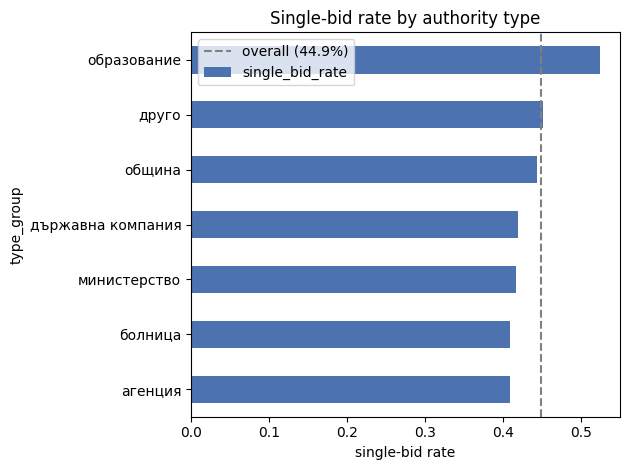

In [5]:
tg = rate_by("type_group")
print(tg.assign(single_bid_rate=tg["single_bid_rate"].round(3)).to_string())

ax = tg["single_bid_rate"].plot(kind="barh", color="#4C72B0")
ax.invert_yaxis()  # highest rate on top
ax.set_xlabel("single-bid rate")
ax.set_title("Single-bid rate by authority type")
ax.axvline(overall_rate, color="grey", linestyle="--",
           label=f"overall ({overall_rate:.1%})")
ax.legend()
plt.tight_layout()
plt.show()

The spread is modest but real. Education bodies sit highest at **52.4%**,
while agencies (40.9%), hospitals (41.0%) and ministries (41.7%) sit a little
below the overall rate. All groups are large enough to trust (the smallest,
ministries, still has ~4.7k contracts). So `type_group` is a mild but genuine
signal - it shifts the rate by roughly ±5 points around the average, nothing
dramatic, but worth keeping as a non-circular feature.

## 3. Single-bid rate by region

`region` (also joined in Section 2, with national-level bodies filled as
`"Unknown"`) lets us look for geographic variation. The caution here is group
size: a high rate on a tiny region is noise, not a finding, so the counts matter
as much as the rates.

                 single_bid_rate  n_single_bid  n_contracts
region                                                     
Кърджали                   0.583          1885         3236
Благоевград                0.548          3113         5676
Бургас                     0.520          4019         7727
София                      0.501          2144         4278
Разград                    0.500           851         1702
Враца                      0.497          2298         4622
Варна                      0.485          4303         8872
Русе                       0.480          2088         4353
Монтана                    0.473          1186         2507
Търговище                  0.465           725         1558
Видин                      0.465           865         1862
Шумен                      0.464          1802         3880
Плевен                     0.462          2026         4382
Ямбол                      0.459          1072         2337
Смолян                     0.453        

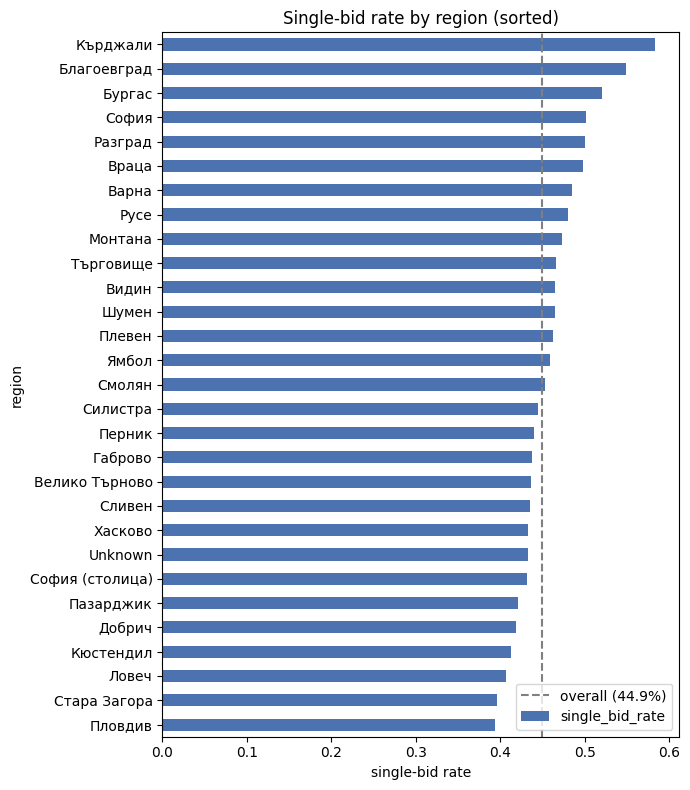

In [6]:
reg = rate_by("region")
print(reg.assign(single_bid_rate=reg["single_bid_rate"].round(3)).to_string())

ax = reg["single_bid_rate"].plot(kind="barh", figsize=(7, 8), color="#4C72B0")
ax.invert_yaxis()
ax.set_xlabel("single-bid rate")
ax.set_title("Single-bid rate by region (sorted)")
ax.axvline(overall_rate, color="grey", linestyle="--",
           label=f"overall ({overall_rate:.1%})")
ax.legend()
plt.tight_layout()
plt.show()

There is real geographic spread - from about **39%** (Plovdiv, Stara
Zagora) up to **58%** (Kardzhali). Some caution is warranted: a few high-rate
regions are small (Razgrad 1.7k, Targovishte 1.6k), so part of the spread at
the top is thin-sample noise. But the pattern is not *only* small-n: Kardzhali
(58% on 3.2k), Blagoevgrad (55% on 5.7k) and Burgas (52% on 7.7k) are all
reasonably sized, while the two largest regions - Sofia-capital (~53.5k) and
Plovdiv (12.9k) - sit at or below the average. So region carries some signal,
but it should be read with group size in mind rather than taken at face value.

## 4. Time features: month, quarter, year-end

The intuition worth testing: contracts rushed through at year-end might attract
fewer bidders. To check it, `signed_at` is parsed into `month`, `quarter`, and a
simple `is_year_end` flag (November-December). These date features are also
candidates for the model later.

In [7]:
# Parse the signing date and engineer simple calendar features.
modelling["signed_dt"] = pd.to_datetime(modelling["signed_at"], errors="coerce")
n_unparsed = modelling["signed_dt"].isna().sum()
print(f"unparseable signed_at rows (excluded from this section): {n_unparsed}")

dated = modelling.dropna(subset=["signed_dt"]).copy()
dated["month"] = dated["signed_dt"].dt.month
dated["quarter"] = dated["signed_dt"].dt.quarter
dated["is_year_end"] = dated["month"].isin([11, 12])

unparseable signed_at rows (excluded from this section): 30


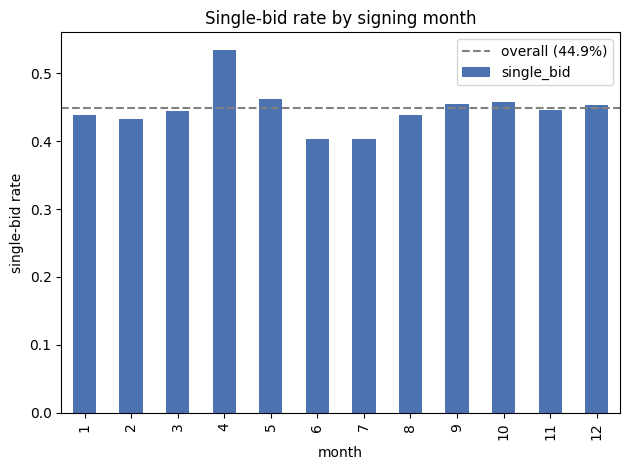

month
1     0.439
2     0.433
3     0.445
4     0.533
5     0.463
6     0.403
7     0.403
8     0.439
9     0.454
10    0.457
11    0.446
12    0.453


In [8]:
# Rate by month, with the overall line for reference.
by_month = dated.groupby("month")["single_bid"].mean()

ax = by_month.plot(kind="bar", color="#4C72B0")
ax.set_ylabel("single-bid rate")
ax.set_xlabel("month")
ax.set_title("Single-bid rate by signing month")
ax.axhline(overall_rate, color="grey", linestyle="--",
           label=f"overall ({overall_rate:.1%})")
ax.legend()
plt.tight_layout()
plt.show()

print(by_month.round(3).to_string())

In [9]:
# The year-end hypothesis, stated plainly: Nov-Dec vs the rest of the year.
ye = (dated.groupby("is_year_end")["single_bid"]
      .agg(single_bid_rate="mean", n_contracts="count"))
print(ye.assign(single_bid_rate=ye["single_bid_rate"].round(3)).to_string())

             single_bid_rate  n_contracts
is_year_end                              
False                  0.449       141066
True                   0.450        33023


The year-end rush hypothesis is **not** supported. November-December
contracts have a single-bid rate of **45.0%**, essentially identical to the
**44.9%** for the rest of the year - within noise. By month there is only a mild
wobble (April a little higher ~53%, June-July a little lower ~40%) with no clean
seasonal story; by quarter the rate is basically flat (43-47%).

That is still a useful result: timing barely moves single-bidding, so `month` /
`quarter` / `is_year_end` are **weak features** at best. They are engineered and
kept for the model to confirm or reject but the EDA already suggests they will
carry little weight.

## 6. Year-to-year trend

Is competition stable over the 2020-2026 window, or trending? Single-bid rate by
signing year shows the movement. Two cautions up front: 2020 (5.7k contracts) and
2026 (15k, a partial year up to the snapshot date) are thinner than the middle
years, so their endpoints are less reliable; and a handful of stray out-of-range
dates are excluded.

      single_bid_rate  n_contracts
year                              
2020            0.488         5747
2021            0.435        26398
2022            0.431        31317
2023            0.454        36112
2024            0.416        18705
2025            0.461        40626
2026            0.491        15180


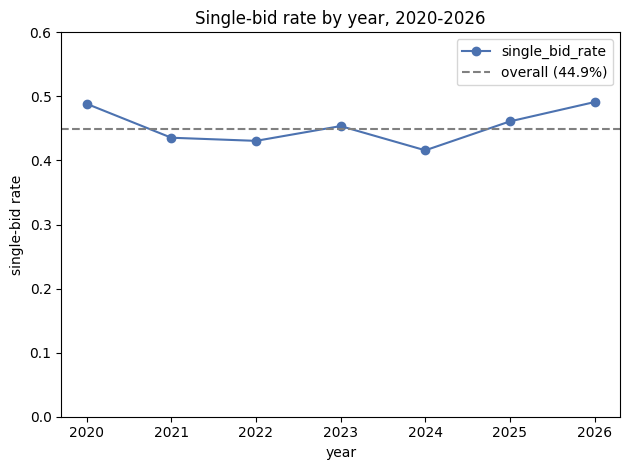

In [10]:
yr = dated[dated["signed_dt"].dt.year.between(2020, 2026)].copy()
yr["year"] = yr["signed_dt"].dt.year
by_year = (yr.groupby("year")["single_bid"]
           .agg(single_bid_rate="mean", n_contracts="count"))
print(by_year.assign(single_bid_rate=by_year["single_bid_rate"].round(3)).to_string())

ax = by_year["single_bid_rate"].plot(kind="line", marker="o", color="#4C72B0")
ax.set_ylabel("single-bid rate"); ax.set_xlabel("year")
ax.set_title("Single-bid rate by year, 2020-2026")
ax.axhline(overall_rate, color="grey", linestyle="--", label=f"overall ({overall_rate:.1%})")
ax.set_ylim(0, 0.6); ax.legend(); plt.tight_layout(); plt.show()

The rate is **relatively stable**, moving in a band roughly 42-49% with no
strong trend up or down. There is mild year-to-year variation - a dip around 2024,
higher readings at the 2020 and 2026 endpoints - but the thin endpoint years make
those edges the least reliable points, so they should not be over-read.

**A note on causes.** This window overlaps real external events - the COVID period
(2020-2022) and a stretch of political instability in Bulgaria (repeated
elections, 2021-2024). It is tempting to tie the wobble to them but **this data
cannot establish any such link**: a rate moving alongside a timeline is not
evidence that a given event caused it. Those events *may* influence procurement
competition but testing that would need a different design and is out of scope
here. The honest reading is simply: single-bidding is broadly stable across the
period, with no dramatic shift that the model would need to account for by year.

## 7. Consolidating the headline trap: `procedure`

The strongest single-bid signal is `procedure`, explored in detail in Section 1.
Brought into the EDA narrative here:

- The direct-award procedure ("Пряко / без обявление") is **~80% single-bid**, far
  above every competitive procedure (~37%).
- That gap is partly **definitional**: a direct award is, by design, made without
  an open call, so a single bid is almost guaranteed. The feature carries
  information that is *near-circular* with the label.
- The European Commission handles this the same way - it excludes direct awards
  from its single-bidder indicator, because the rules for those procedures make no
  provision for competition.

This is the project's **headline methodological limitation** - a modelling
decision to be made openly, not a cleaning fix. At the modelling stage the plan is
to run the models **with and without** the direct-award procedure, so its effect
on the scores is visible and the model is shown not to be merely a direct-award
detector (Section 1 established that ~78% of single-bid contracts are *not* direct
awards).

## 8. Single-bid rate by contract value (EUR)

Section 1 showed `value_eur` is heavily right-skewed (median 23k, max 1.3bn).
The question for competition: do larger contracts attract more bidders? Bigger
contracts are more worth competing for, so a falling single-bid rate as value
rises would be the expected pattern. Contracts are bucketed by value (a robust way
to read a skewed variable) and the rate computed per bucket.

           single_bid_rate  n_single_bid  n_contracts
value_eur                                            
<10k                 0.461         28583        62007
10-50k               0.452         24521        54301
50-250k              0.458         17472        38129
250k-1M              0.400          5322        13294
>1M                  0.354          2260         6388


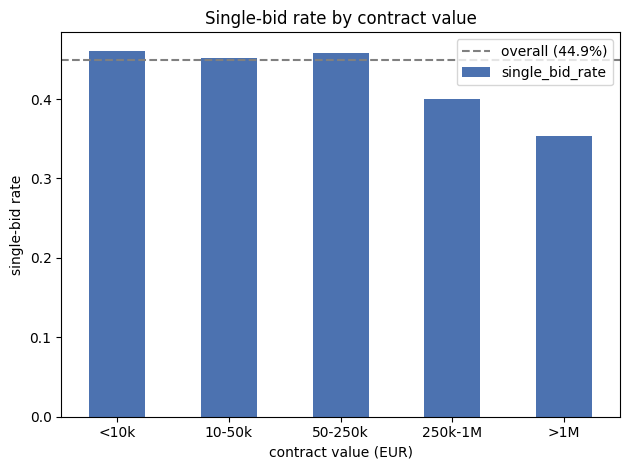

In [11]:
# Bucket by contract value and compute single-bid rate per bucket.
buckets = pd.cut(modelling["value_eur"],
                 bins=[-1, 10_000, 50_000, 250_000, 1_000_000, 1e12],
                 labels=["<10k", "10-50k", "50-250k", "250k-1M", ">1M"])
val = (modelling.groupby(buckets, observed=True)["single_bid"]
       .agg(single_bid_rate="mean", n_single_bid="sum", n_contracts="count"))
val["n_single_bid"] = val["n_single_bid"].astype(int)
print(val.assign(single_bid_rate=val["single_bid_rate"].round(3)).to_string())

ax = val["single_bid_rate"].plot(kind="bar", color="#4C72B0")
ax.set_xticklabels(val.index, rotation=0)
ax.set_ylabel("single-bid rate"); ax.set_xlabel("contract value (EUR)")
ax.set_title("Single-bid rate by contract value")
ax.axhline(overall_rate, color="grey", linestyle="--", label=f"overall ({overall_rate:.1%})")
ax.legend(); plt.tight_layout(); plt.show()

A clear, interpretable pattern. For small and mid-size contracts (up to
250k) the single-bid rate is flat around **45-46%**. Above that it falls -
**40.0%** in the 250k-1M band and **35.4%** above 1M. Larger contracts attract
more competition, which is the expected direction: a bigger prize is worth more
bidders' effort. `value_eur` is a genuine, non-circular signal, and this supports
the plan to keep it (log-transformed, given the skew) as a model feature.

## Section 3 - findings & decisions

**What the breakdowns show (all rates computed with counts, on the 174,119-row
cleaned table):**

- **EU funding is the cleanest new signal.** EU-funded contracts are single-bid
  **36.0%** vs **46.3%** nationally - a ~10-point gap that *survives* removing
  direct awards (41.1% vs 33.7%), so it is real, not a circularity artefact.
- **Contract value matters at the top end.** Flat ~45-46% up to ~250k, then
  falling to **40.0%** (250k-1M) and **35.4%** (>1M). Bigger contracts draw more
  bidders. Supports keeping `value_eur` (log-transformed) as a feature.
- **Authority type is a mild signal.** Education highest (52.4%); agencies,
  hospitals, ministries a few points below average (~41%). All groups large enough
  to trust.
- **Region has real but uneven spread** (~39% to ~58%). Partly small-sample noise
  at the high end, but the larger regions differ genuinely. Read with group size
  in mind.
- **Time barely matters.** Year-end rush rejected (Nov-Dec 45.0% ≈ rest 44.9%);
  month and quarter nearly flat. Date features kept but expected weak.
- **The year trend is broadly stable** (~42-49%, no strong direction). External
  events (COVID, political instability) overlap the window but the data cannot
  attribute cause - stated as a limit, not an explanation.
- **Sector (CPV division) was explored in Section 1** and is kept as a
  non-circular feature. Single-bid rates vary by sector in line with market
  thinness (some product/service markets simply have fewer capable suppliers).
  Caveat: sector partly confounds with `procedure` — thin-market sectors may
  lean on direct awards — so its standalone effect is read with that in mind and
  left for the model to weigh.

**The headline trap stays `procedure`.** Direct awards are ~80% single-bid and
near-circular with the label by definition; consolidated here, handled at the
modelling stage (with/without), mirroring the EC's own treatment.

**Decisions carried forward:**
- Keep `eu_funded` (strong), `value_eur` (log-transformed), `type_group` and
  `region` (milder) as non-circular features.
- Keep the date features but flag them as weak; let the model confirm.
- Treat `procedure` as the documented circularity risk, not a feature to drop
  silently.
- Keep `sector_code` (CPV division) as a non-circular feature, explored in
  Section 1; note the procedure confound rather than treating its rate as a
  clean effect.

**Next (Section 4):** a naive baseline to beat, then logistic
regression - encoding the categoricals, log-transforming `value_eur`, and running
the procedure with/without experiment.